Supervised machine learning with decision trees

We predict smoking status (**No = 0, Yes = 1**) from **recorded medical charges, age and BMI**. This uses the same classification question as Task 3, with a different algorithm. Charges must already be known when this model is used; these are not predictions made before medical costs occur.

We compare three depth settings and three minimum leaf-size settings, reusing the unrestricted baseline. We select settings using validation F1-score, evaluate the final tree on held-out test records, and compare its predictions with rules extracted from the same tree.

Source: [Medical Cost Personal Dataset on Kaggle](https://www.kaggle.com/datasets/mirichoi0218/insurance). These are classroom results, not evidence of causation or guaranteed performance outside this dataset.

Dataset and preparation

Preparation was completed in Task 1. No missing values or inconsistent category labels were found. One exact duplicate was removed, leaving 1,337 records. Plausible extreme values and records with young ages and covered dependents were retained.

We load `insurance_cleaned.csv` and select three numerical inputs. Only the target needs yes/no encoding. Decision trees do not require scaling, so all inputs remain in their original units.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)

df = pd.read_csv("insurance_cleaned.csv")
X = df[["charges", "age", "bmi"]].copy()
y = df["smoker"].map({"no": 0, "yes": 1})

print("Dataset shape:", df.shape)
print("Missing input values:", X.isnull().sum().sum())
print("Missing target values:", y.isnull().sum())
print("Exact duplicate rows:", df.duplicated().sum())
display(X.head())

Dataset shape: (1337, 9)
Missing input values: 0
Missing target values: 0
Exact duplicate rows: 0


,charges,age,bmi
0,16884.92400,19,27.900
1,1725.55230,18,33.770
2,4449.46200,28,33.000
3,21984.47061,33,22.705
4,3866.85520,32,28.880


Split the data

First reserve 20% for the final test. Split the remaining 80% into training and validation data, giving approximately **60% training, 20% validation and 20% test** overall.

Stratification keeps similar smoker proportions in all three parts. We use the same split for every experiment. The test results are not used to choose settings.

In [2]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train, X_validation, y_train, y_validation = train_test_split(
    X_dev, y_dev, test_size=0.25, random_state=42, stratify=y_dev
)

split_summary = pd.DataFrame({
    "Part": ["Training", "Validation", "Test"],
    "Rows": [len(X_train), len(X_validation), len(X_test)],
    "Smokers (%)": [y_train.mean() * 100, y_validation.mean() * 100, y_test.mean() * 100]
})
display(split_summary.round(2))

,Part,Rows,Smokers (%)
0,Training,801,20.47
1,Validation,268,20.52
2,Test,268,20.52


Compare models consistently

We use **F1-score for smokers** to select settings because the classes are unequal and both missed smokers and false alarms matter. We also show accuracy, precision and recall. Training and validation F1 together help show possible overfitting.

This small helper avoids repeating the same evaluation code for every experiment. It does not inspect the test data.

In [3]:
def evaluate_candidate(name, model):
    train_predictions = model.predict(X_train)
    validation_predictions = model.predict(X_validation)

    return {
        "Model": name,
        "Depth limit": "None" if model.max_depth is None else model.max_depth,
        "Minimum leaf size": model.min_samples_leaf,
        "Actual depth": model.get_depth(),
        "Leaves": model.get_n_leaves(),
        "Nodes": model.tree_.node_count,
        "Training F1": f1_score(y_train, train_predictions, zero_division=0),
        "Validation F1": f1_score(y_validation, validation_predictions, zero_division=0),
        "Validation accuracy": accuracy_score(y_validation, validation_predictions),
        "Validation precision": precision_score(y_validation, validation_predictions, zero_division=0),
        "Validation recall": recall_score(y_validation, validation_predictions, zero_division=0)
    }

Depth experiments

Start with no depth limit and minimum leaf size 1. Record its actual depth D. Compare this baseline with depth limits D//2 and then half of that limit, never below 1. Integer division rounds down. All other settings stay the same.

For this dataset and split, the baseline reaches depth 10, giving limits **None, 5 and 2**. Halving is a simple planned experiment, not a search over every possible depth.

In [4]:
models = {}

baseline = DecisionTreeClassifier(max_depth=None, min_samples_leaf=1, random_state=42)
baseline.fit(X_train, y_train)
models["Unrestricted"] = baseline

full_depth = baseline.get_depth()
half_depth = max(1, full_depth // 2)
quarter_depth = max(1, half_depth // 2)

print("Unrestricted depth:", full_depth)
print("Second depth limit:", half_depth)
print("Third depth limit:", quarter_depth)

depth_rows = [evaluate_candidate("Unrestricted", baseline)]

for depth in sorted(set([half_depth, quarter_depth]), reverse=True):
    name = f"Depth {depth}"
    model = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=1, random_state=42)
    model.fit(X_train, y_train)
    models[name] = model
    depth_rows.append(evaluate_candidate(name, model))

depth_results = pd.DataFrame(depth_rows)
display(depth_results.round(3))

Unrestricted depth: 10
Second depth limit: 5
Third depth limit: 2


,Model,Depth limit,Minimum leaf size,Actual depth,Leaves,Nodes,Training F1,Validation F1,Validation accuracy,Validation precision,Validation recall
0,Unrestricted,None,1,10,30,59,1.000,0.919,0.966,0.911,0.927
1,Depth 5,5,1,5,14,27,0.945,0.930,0.970,0.898,0.964
2,Depth 2,2,1,2,4,7,0.824,0.864,0.937,0.771,0.982


Minimum leaf-size experiments

A leaf is an endpoint that makes a prediction. `min_samples_leaf` sets the minimum number of **training records in each leaf**, not the number of leaves.

Keep depth unrestricted and compare **1, 5 and 10** records per leaf. The size-1 model is the existing unrestricted baseline, so we reuse it. Larger minimums prevent very small leaves.

In [5]:
leaf_rows = [evaluate_candidate("Unrestricted", baseline)]

for leaf_size in [5, 10]:
    name = f"Leaf minimum {leaf_size}"
    model = DecisionTreeClassifier(max_depth=None, min_samples_leaf=leaf_size, random_state=42)
    model.fit(X_train, y_train)
    models[name] = model
    leaf_rows.append(evaluate_candidate(name, model))

leaf_results = pd.DataFrame(leaf_rows)
display(leaf_results.round(3))

,Model,Depth limit,Minimum leaf size,Actual depth,Leaves,Nodes,Training F1,Validation F1,Validation accuracy,Validation precision,Validation recall
0,Unrestricted,None,1,10,30,59,1.000,0.919,0.966,0.911,0.927
1,Leaf minimum 5,None,5,8,19,37,0.951,0.911,0.963,0.895,0.927
2,Leaf minimum 10,None,10,6,13,25,0.920,0.929,0.970,0.912,0.945


Visualize the experiments

Compare validation F1, not training F1 alone. A perfect training score with weaker validation performance suggests overfitting. All models were evaluated on the same validation records.

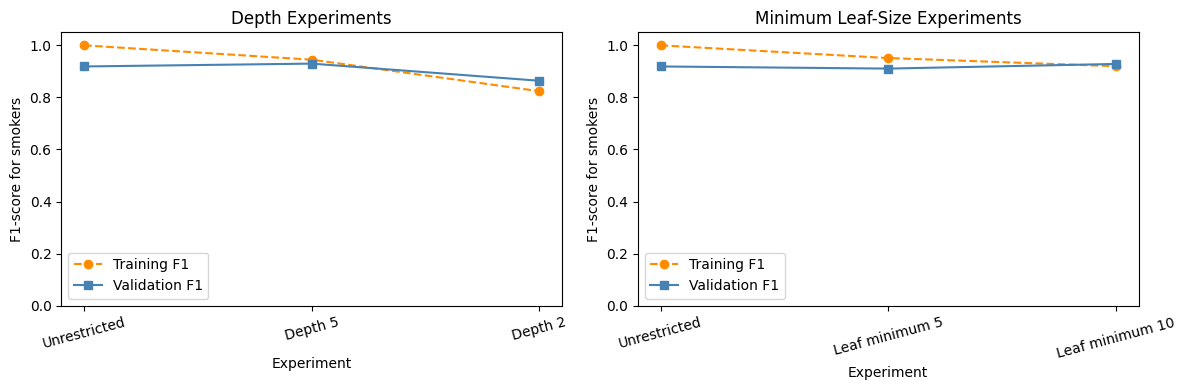

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, results, title in zip(
    axes, [depth_results, leaf_results], ["Depth Experiments", "Minimum Leaf-Size Experiments"]
):
    ax.plot(results["Model"], results["Training F1"], "o--", color="darkorange", label="Training F1")
    ax.plot(results["Model"], results["Validation F1"], "s-", color="steelblue", label="Validation F1")
    ax.set_title(title)
    ax.set_xlabel("Experiment")
    ax.set_ylabel("F1-score for smokers")
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=15)
    ax.legend()

plt.tight_layout()
plt.show()

Select settings using validation data

Choose the highest validation F1. If scores tie exactly, choose fewer nodes, then a shallower tree. Report a winner in each experiment and choose the final settings from the five unique candidates. We do not combine settings that were not tested or use test scores to choose a winner.

In [7]:
ranking_columns = ["Validation F1", "Nodes", "Actual depth"]
ranking_order = [False, True, True]

best_depth = depth_results.sort_values(ranking_columns, ascending=ranking_order).iloc[0]
best_leaf = leaf_results.sort_values(ranking_columns, ascending=ranking_order).iloc[0]

all_results = pd.concat([depth_results, leaf_results], ignore_index=True)
all_results = all_results.drop_duplicates(subset="Model")
ranked_results = all_results.sort_values(ranking_columns, ascending=ranking_order)
best_name = ranked_results.iloc[0]["Model"]
selected_model = models[best_name]

print("Best depth experiment:", best_depth["Model"])
print("Best leaf-size experiment:", best_leaf["Model"])
print("Selected candidate:", best_name)
display(ranked_results.round(3))

Best depth experiment: Depth 5
Best leaf-size experiment: Leaf minimum 10
Selected candidate: Depth 5


,Model,Depth limit,Minimum leaf size,Actual depth,Leaves,Nodes,Training F1,Validation F1,Validation accuracy,Validation precision,Validation recall
1,Depth 5,5,1,5,14,27,0.945,0.930,0.970,0.898,0.964
5,Leaf minimum 10,None,10,6,13,25,0.920,0.929,0.970,0.912,0.945
0,Unrestricted,None,1,10,30,59,1.000,0.919,0.966,0.911,0.927
4,Leaf minimum 5,None,5,8,19,37,0.951,0.911,0.963,0.895,0.927
2,Depth 2,2,1,2,4,7,0.824,0.864,0.937,0.771,0.982


Fit the final tree

Keep the selected settings fixed and train once on the combined training and validation data (80%). This uses more records for the final fit. Its exact structure may change after refitting; the selection scores above belong to the original training fits. The final test data remains unused until evaluation below.

In [8]:
final_tree = DecisionTreeClassifier(
    max_depth=selected_model.max_depth,
    min_samples_leaf=selected_model.min_samples_leaf,
    random_state=42
)
final_tree.fit(X_dev, y_dev)

print("Selected depth limit:", final_tree.max_depth)
print("Selected minimum leaf size:", final_tree.min_samples_leaf)
print("Final training rows:", len(X_dev))
print("Final actual depth:", final_tree.get_depth())
print("Final number of leaves:", final_tree.get_n_leaves())
print("Final number of nodes:", final_tree.tree_.node_count)
print("Split criterion:", final_tree.criterion)

Selected depth limit: 5
Selected minimum leaf size: 1
Final training rows: 1069
Final actual depth: 5
Final number of leaves: 16
Final number of nodes: 31
Split criterion: gini


Evaluate the final tree on the test data

Accuracy is the fraction of correct predictions. Precision is the fraction of predicted smokers who are smokers. Recall is the fraction of smokers identified. F1 balances precision and recall. ROC-AUC uses probabilities to assess ranking across thresholds.

The tree predicts the majority class in each leaf; a tied leaf selects class 0. Its smoking probability is the smoker fraction among training records in that leaf. These probabilities need not be well calibrated.

In [9]:
test_predictions = final_tree.predict(X_test)
test_probabilities = final_tree.predict_proba(X_test)[:, 1]

def classification_scores(actual, predictions, probabilities):
    return {
        "Accuracy": accuracy_score(actual, predictions),
        "Precision": precision_score(actual, predictions, zero_division=0),
        "Recall": recall_score(actual, predictions, zero_division=0),
        "F1-score": f1_score(actual, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(actual, probabilities)
    }

tree_scores = classification_scores(y_test, test_predictions, test_probabilities)
display(pd.Series(tree_scores, name="Test score").to_frame().round(3))
print(f"Always predict non-smoker accuracy: {(y_test == 0).mean():.3f}")
print("Test records:", len(y_test))

,Test score
Accuracy,0.974
Precision,0.944
Recall,0.927
F1-score,0.936
ROC-AUC,0.979


Always predict non-smoker accuracy: 0.795
Test records: 268


Confusion matrix and ROC curve

In the matrix, rows are actual outcomes and columns are predictions. The diagonal contains correct predictions. The ROC curve shows how recall and the false-positive rate change with the probability threshold.

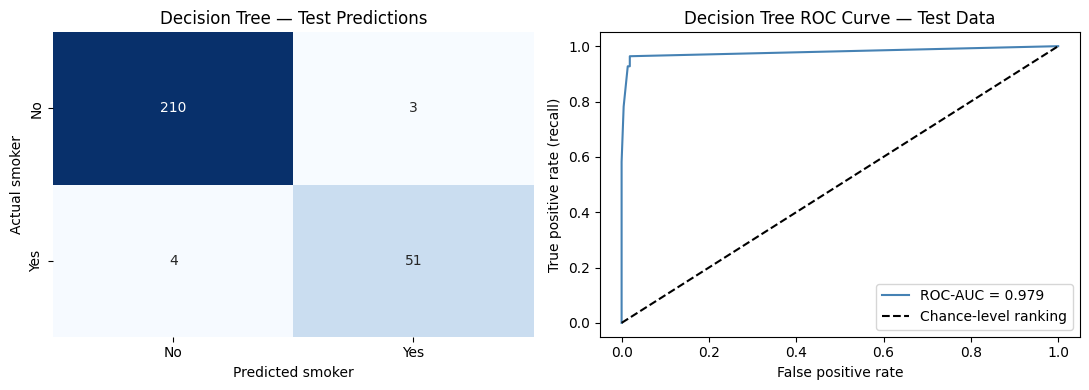

In [10]:
matrix = confusion_matrix(y_test, test_predictions, labels=[0, 1])
fpr, tpr, thresholds = roc_curve(y_test, test_probabilities)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(
    matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["No", "Yes"], yticklabels=["No", "Yes"], ax=axes[0]
)
axes[0].set_title("Decision Tree — Test Predictions")
axes[0].set_xlabel("Predicted smoker")
axes[0].set_ylabel("Actual smoker")

axes[1].plot(fpr, tpr, color="steelblue", label=f"ROC-AUC = {tree_scores['ROC-AUC']:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", label="Chance-level ranking")
axes[1].set_title("Decision Tree ROC Curve — Test Data")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate (recall)")
axes[1].legend()
plt.tight_layout()
plt.show()

Visualize the final tree

Start at the root. Follow the left branch when a condition is true, and the right branch when it is false. Each leaf gives the predicted class. `samples` counts development-set records reaching a node; `value` shows class counts or proportions, depending on the library version. No test labels are used to build the tree.

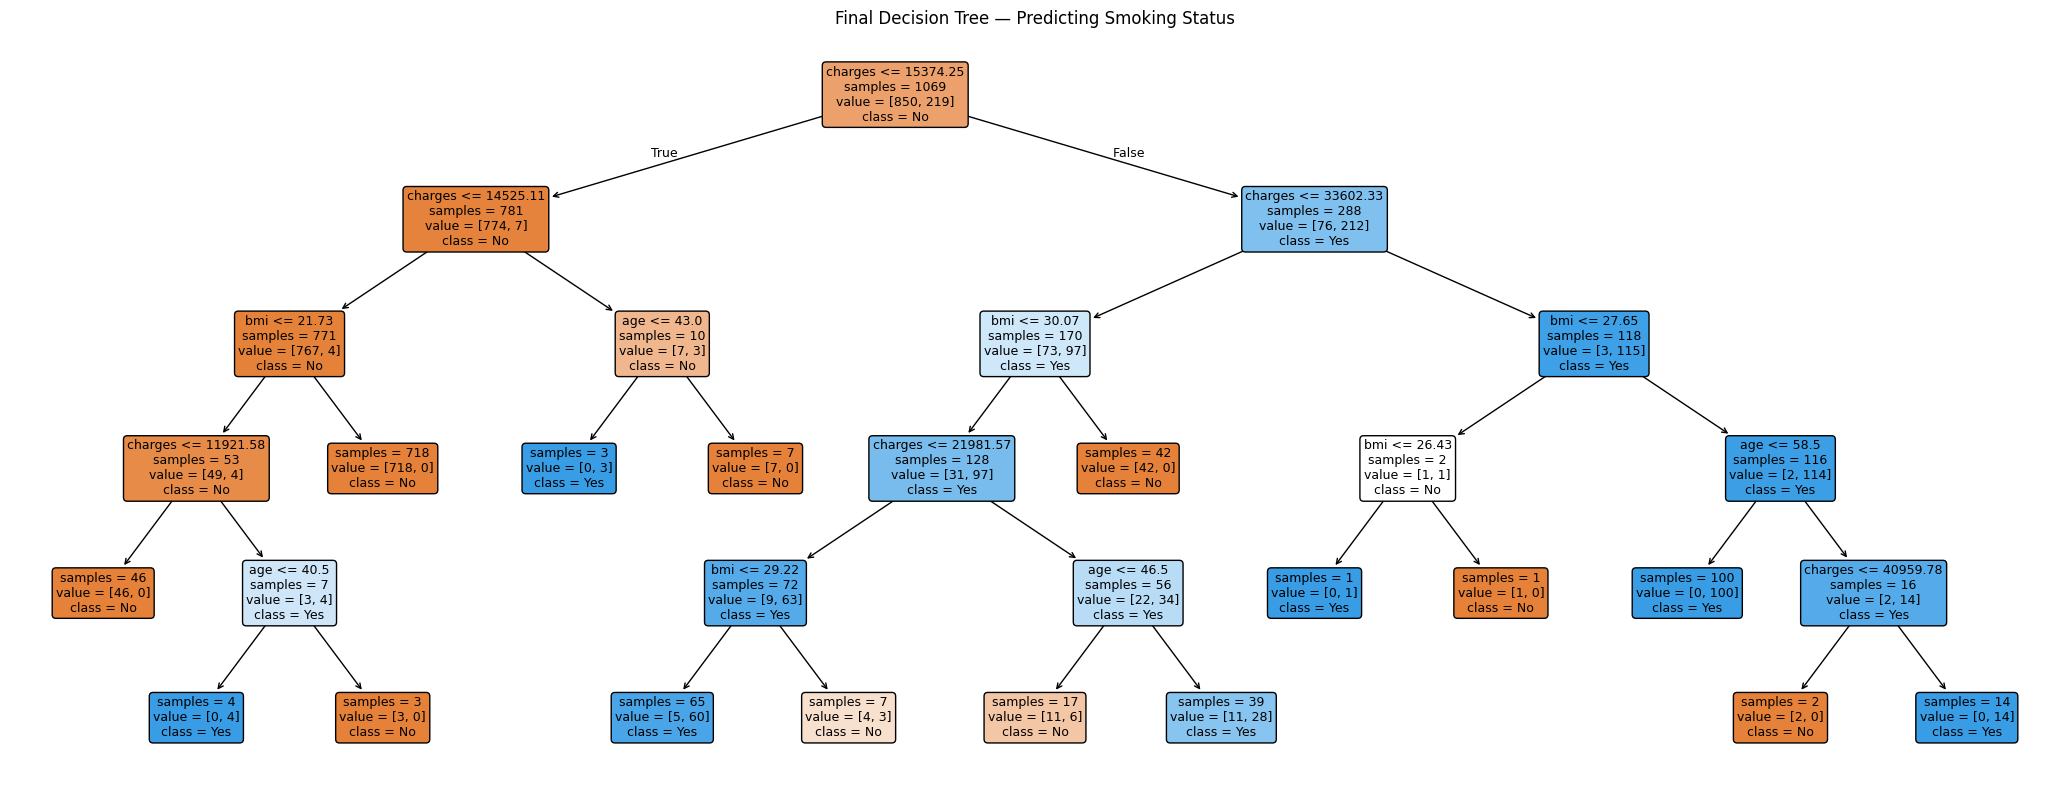

In [11]:
plt.figure(figsize=(max(16, final_tree.get_n_leaves() * 1.3), max(8, final_tree.get_depth() * 1.5)))
plot_tree(
    final_tree, feature_names=list(X.columns), class_names=["No", "Yes"],
    filled=True, rounded=True, impurity=False, precision=2, fontsize=9
)
plt.title("Final Decision Tree — Predicting Smoking Status")
plt.tight_layout()
plt.show()

Feature importance

These values describe how much each input contributed to reducing impurity in this fitted tree. They are not causal effects and can vary across splits.

,Importance
charges,0.830
age,0.036
bmi,0.134


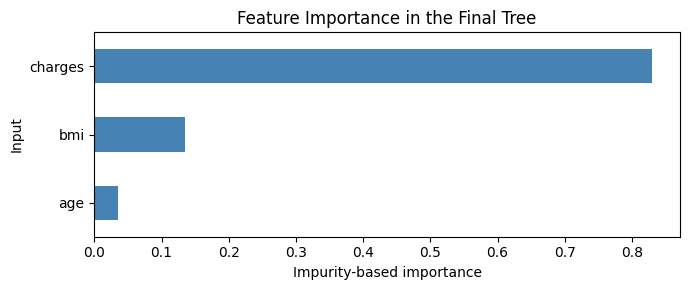

In [12]:
importance = pd.Series(final_tree.feature_importances_, index=X.columns)
display(importance.rename("Importance").to_frame().round(3))

importance.sort_values().plot.barh(figsize=(7, 3), color="steelblue")
plt.title("Feature Importance in the Final Tree")
plt.xlabel("Impurity-based importance")
plt.ylabel("Input")
plt.tight_layout()
plt.show()

Optional: extract IF–THEN decision rules

Each root-to-leaf path becomes one rule. The function below follows both branches, stores the conditions and records the leaf's predicted class and smoking probability. It uses the fitted tree only to extract the rules.

Displayed cutoffs are rounded for readability. The executable rules retain full-precision thresholds, so classification does not depend on rounded text.

In [13]:
rules = []
tree = final_tree.tree_
feature_names = list(X.columns)

def extract_rules(node=0, conditions=None):
    if conditions is None:
        conditions = []

    left = tree.children_left[node]
    right = tree.children_right[node]

    if left == right:
        values = tree.value[node][0]
        rules.append({
            "conditions": conditions,
            "prediction": int(final_tree.classes_[np.argmax(values)]),
            "probability": float(values[1] / values.sum()),
            "training_rows": int(tree.n_node_samples[node])
        })
    else:
        feature = feature_names[tree.feature[node]]
        cutoff = float(tree.threshold[node])
        extract_rules(left, conditions + [(feature, "<=", cutoff)])
        extract_rules(right, conditions + [(feature, ">", cutoff)])

extract_rules()

for number, rule in enumerate(rules, start=1):
    conditions_text = " AND ".join(
        f"{feature} {operator} {cutoff:.6f}"
        for feature, operator, cutoff in rule["conditions"]
    ) or "all records"
    label = "Yes" if rule["prediction"] == 1 else "No"
    print(f"Rule {number}: IF {conditions_text}")
    print(f"THEN smoker = {label}; probability of Yes = {rule['probability']:.3f}; training rows = {rule['training_rows']}.")
    print()

Rule 1: IF charges <= 15374.252441 AND charges <= 14525.110352 AND bmi <= 21.727500 AND charges <= 11921.583496
THEN smoker = No; probability of Yes = 0.000; training rows = 46.

Rule 2: IF charges <= 15374.252441 AND charges <= 14525.110352 AND bmi <= 21.727500 AND charges > 11921.583496 AND age <= 40.500000
THEN smoker = Yes; probability of Yes = 1.000; training rows = 4.

Rule 3: IF charges <= 15374.252441 AND charges <= 14525.110352 AND bmi <= 21.727500 AND charges > 11921.583496 AND age > 40.500000
THEN smoker = No; probability of Yes = 0.000; training rows = 3.

Rule 4: IF charges <= 15374.252441 AND charges <= 14525.110352 AND bmi > 21.727500
THEN smoker = No; probability of Yes = 0.000; training rows = 718.

Rule 5: IF charges <= 15374.252441 AND charges > 14525.110352 AND age <= 43.000000
THEN smoker = Yes; probability of Yes = 1.000; training rows = 3.

Rule 6: IF charges <= 15374.252441 AND charges > 14525.110352 AND age > 43.000000
THEN smoker = No; probability of Yes = 0.0

Classify using the rules

This code checks the stored conditions directly; it does not call the tree's prediction methods. We match scikit-learn's float32 input conversion so comparisons use the same numerical precision. Every row must match exactly one rule.

In [14]:
def predict_with_rules(data, rules):
    inputs = data.astype(np.float32)
    predictions = np.full(len(inputs), -1, dtype=int)
    probabilities = np.full(len(inputs), np.nan)
    match_count = np.zeros(len(inputs), dtype=int)

    for rule in rules:
        matches = np.ones(len(inputs), dtype=bool)
        for feature, operator, cutoff in rule["conditions"]:
            values = inputs[feature].to_numpy().astype(np.float64)
            if operator == "<=":
                matches &= values <= cutoff
            else:
                matches &= values > cutoff

        predictions[matches] = rule["prediction"]
        probabilities[matches] = rule["probability"]
        match_count[matches] += 1

    assert (match_count == 1).all(), "Each row must match exactly one rule."
    return predictions, probabilities

rule_predictions, rule_probabilities = predict_with_rules(X_test, rules)
rule_scores = classification_scores(y_test, rule_predictions, rule_probabilities)

print("Extracted rules:", len(rules))
print("Different class predictions:", (test_predictions != rule_predictions).sum())
print("Same probabilities:", np.allclose(test_probabilities, rule_probabilities))

model_comparison = pd.DataFrame({"Decision tree": tree_scores, "Extracted rules": rule_scores})
display(model_comparison.round(3))

Extracted rules: 16
Different class predictions: 0
Same probabilities: True


,Decision tree,Extracted rules
Accuracy,0.974,0.974
Precision,0.944,0.944
Recall,0.927,0.927
F1-score,0.936,0.936
ROC-AUC,0.979,0.979


Why the results match

The rules are an exact translation of this tree. They should make identical predictions, not outperform it. Agreement confirms that the rule-based classifier reproduces the tree. Simplifying or pruning the rules would create a different model requiring a new validation step.

In [15]:
prediction_examples = X_test.head(10).copy()
prediction_examples["Actual smoker"] = y_test.head(10).map({0: "No", 1: "Yes"})
prediction_examples["Tree prediction"] = np.where(test_predictions[:10] == 1, "Yes", "No")
prediction_examples["Rule prediction"] = np.where(rule_predictions[:10] == 1, "Yes", "No")
prediction_examples["Probability of Yes"] = test_probabilities[:10]
display(prediction_examples.round(3))

,charges,age,bmi,Actual smoker,Tree prediction,Rule prediction,Probability of Yes
575,12222.898,58,27.170,No,No,No,0.000
931,10096.970,46,25.800,No,No,No,0.000
955,41999.520,54,30.800,Yes,Yes,Yes,1.000
144,20745.989,30,28.690,Yes,Yes,Yes,0.923
683,4766.022,33,18.500,No,No,No,0.000
632,7173.360,40,22.705,No,No,No,0.000
613,1880.070,20,33.000,No,No,No,0.000
1100,11253.421,53,28.600,No,No,No,0.000
701,9504.310,53,41.470,No,No,No,0.000
968,8596.828,39,34.320,No,No,No,0.000


Results in plain language

The unrestricted tree fits the training data perfectly, but its validation F1 is lower than the depth-5 tree. This suggests overfitting. Reducing the depth to 2 lowers both training and validation F1, suggesting the tree is too simple.

Requiring at least 10 records per leaf improves validation F1 compared with the unrestricted baseline; requiring 5 does not improve it on this split. Depth 5 gives the highest validation F1 among our candidates, although its advantage over a minimum leaf size of 10 is very small (about 0.001). A different split could change their ranking.

We choose depth 5 using validation results, then refit and evaluate once on the test set. The extracted rules reproduce this final tree exactly.

In [16]:
print(f"We evaluated {len(all_results)} unique candidates across two sets of three experiments, sharing one baseline.")
print(f"The unrestricted baseline reached depth {full_depth}; the other depth limits were {half_depth} and {quarter_depth}.")
print(f"The best depth experiment was {best_depth['Model']} (validation F1 = {best_depth['Validation F1']:.3f}).")
print(f"The best leaf-size experiment was {best_leaf['Model']} (validation F1 = {best_leaf['Validation F1']:.3f}).")
print(f"We selected {best_name} using validation F1, with simpler trees preferred for exact ties.")
print(f"After refitting on 80% of the data, the final tree has depth {final_tree.get_depth()} and {final_tree.get_n_leaves()} leaves.")
print(f"On the held-out test data, accuracy is {tree_scores['Accuracy']:.1%}, F1 is {tree_scores['F1-score']:.3f}, and ROC-AUC is {tree_scores['ROC-AUC']:.3f}.")
print(f"The rule classifier disagrees with the tree on {(test_predictions != rule_predictions).sum()} test records.")
print("These settings are best among the candidates tested, not proven best among every possible tree.")

We evaluated 5 unique candidates across two sets of three experiments, sharing one baseline.
The unrestricted baseline reached depth 10; the other depth limits were 5 and 2.
The best depth experiment was Depth 5 (validation F1 = 0.930).
The best leaf-size experiment was Leaf minimum 10 (validation F1 = 0.929).
We selected Depth 5 using validation F1, with simpler trees preferred for exact ties.
After refitting on 80% of the data, the final tree has depth 5 and 16 leaves.
On the held-out test data, accuracy is 97.4%, F1 is 0.936, and ROC-AUC is 0.979.
The rule classifier disagrees with the tree on 0 test records.
These settings are best among the candidates tested, not proven best among every possible tree.
